In [14]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, precision_recall_curve, average_precision_score, confusion_matrix
import torch
from sklearn.metrics import f1_score
from datasets import Dataset
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import os

def strip_html(text: str) -> str:
    text = str(text)
    # remove tags
    text = re.sub(r"<[^>]+>", " ", text)
    # collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

def to_binary_label(label_0_4: int) -> int:
    # official mapping from paper/spec
    return 0 if int(label_0_4) in (0, 1) else 1

In [2]:
DATA_TSV = "/kaggle/input/datasets/temirlansergazin/dataset/dontpatronizeme_pcl.tsv"

df = pd.read_csv(
    DATA_TSV,
    sep="\t",
    header=None,
    names=["par_id", "art_id", "keyword", "country", "text", "label"],
    engine="python",
    quoting=3,
    on_bad_lines="skip"
)

# Coerce numeric fields
df["par_id"] = pd.to_numeric(df["par_id"], errors="coerce")
df["label"]  = pd.to_numeric(df["label"], errors="coerce")

# Count issues before fixing
print("NaN par_id:", df["par_id"].isna().sum())
print("NaN label:", df["label"].isna().sum())
print("NaN text:", df["text"].isna().sum())

# Fill text if missing
df["text"] = df["text"].fillna("")

# Remove rows where par_id or label failed numeric parsing
df = df[df["par_id"].notna()]
df = df[df["label"].notna()]

df["par_id"] = df["par_id"].astype(int)
df["label"]  = df["label"].astype(int)

# Clean text
df["text"] = df["text"].apply(strip_html)

# Binary mapping
df["label_bin"] = df["label"].apply(to_binary_label)

print("Final shape:", df.shape)

NaN par_id: 3
NaN label: 3
NaN text: 4
Final shape: (10469, 7)


In [3]:
TRAIN_SPLIT = "/kaggle/input/datasets/temirlansergazin/dataset/train_semeval_parids-labels.csv"
DEV_SPLIT   = "/kaggle/input/datasets/temirlansergazin/dataset/dev_semeval_parids-labels.csv"

train_ids = pd.read_csv(TRAIN_SPLIT)["par_id"].astype(int).tolist()
dev_ids   = pd.read_csv(DEV_SPLIT)["par_id"].astype(int).tolist()

train_df = df[df["par_id"].isin(train_ids)][["par_id", "text", "label_bin"]].copy()
dev_df   = df[df["par_id"].isin(dev_ids)][["par_id", "text", "label_bin"]].copy()

print("train:", train_df.shape, "dev:", dev_df.shape)
train_df["label_bin"].value_counts(), dev_df["label_bin"].value_counts()

train: (8375, 3) dev: (2094, 3)


(label_bin
 0    7581
 1     794
 Name: count, dtype: int64,
 label_bin
 0    1895
 1     199
 Name: count, dtype: int64)

In [4]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
dev_ds   = Dataset.from_pandas(dev_df.reset_index(drop=True))

train_ds, dev_ds

(Dataset({
     features: ['par_id', 'text', 'label_bin'],
     num_rows: 8375
 }),
 Dataset({
     features: ['par_id', 'text', 'label_bin'],
     num_rows: 2094
 }))

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "roberta-base"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
dev_tok   = dev_ds.map(tokenize_batch, batched=True)

cols_to_remove = ["text"]
train_tok = train_tok.remove_columns([c for c in cols_to_remove if c in train_tok.column_names])
dev_tok   = dev_tok.remove_columns([c for c in cols_to_remove if c in dev_tok.column_names])

train_tok = train_tok.rename_column("label_bin", "labels")
dev_tok   = dev_tok.rename_column("label_bin", "labels")

train_tok.set_format("torch")
dev_tok.set_format("torch")

# sanity check labels
batch = next(iter(torch.utils.data.DataLoader(train_tok, batch_size=64)))
print("Label dtype:", batch["labels"].dtype)
print("Unique labels in a batch:", torch.unique(batch["labels"]))

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

Label dtype: torch.int64
Unique labels in a batch: tensor([0, 1])


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
y = train_df["label_bin"].values
n0 = (y == 0).sum()
n1 = (y == 1).sum()

w0 = 1.0
w1 = n0 / max(n1, 1)

class_weights = torch.tensor([w0, w1], dtype=torch.float32)
print("n0:", n0, "n1:", n1)
print("class_weights:", class_weights)

n0: 7581 n1: 794
class_weights: tensor([1.0000, 9.5479])


In [7]:


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = (probs[:, 1] >= 0.5).astype(int)

    f1_pos = f1_score(labels, preds, pos_label=1)
    prec   = precision_score(labels, preds, pos_label=1, zero_division=0)
    rec    = recall_score(labels, preds, pos_label=1, zero_division=0)
    return {"f1_pos": f1_pos, "precision_pos": prec, "recall_pos": rec}

class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"].long()
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits

        # match device + dtype
        weights = self.class_weights.to(device=logits.device, dtype=logits.dtype)

        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

args = TrainingArguments(
    output_dir="bestmodel_deberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=1.5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_pos",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=42,
    fp16=False,
    bf16=False
)

trainer = WeightedLossTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=dev_tok,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [8]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Pos,Precision Pos,Recall Pos
1,0.481262,0.417207,0.469136,0.322642,0.859296
2,0.395856,0.356477,0.515050,0.385965,0.773869
3,0.228676,0.377548,0.560636,0.463816,0.708543
4,0.214917,0.420425,0.572008,0.479592,0.708543


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1048, training_loss=0.3427301508779744, metrics={'train_runtime': 954.6965, 'train_samples_per_second': 35.09, 'train_steps_per_second': 1.098, 'total_flos': 4407110177280000.0, 'train_loss': 0.3427301508779744, 'epoch': 4.0})

In [9]:
pred = trainer.predict(dev_tok)
logits = pred.predictions
labels = pred.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
best_t, best_f1 = 0.5, -1

for t in thresholds:
    yhat = (probs >= t).astype(int)
    f1 = f1_score(labels, yhat, pos_label=1)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", best_t, "Best dev F1(pos):", best_f1)

yhat_best = (probs >= best_t).astype(int)
print(classification_report(labels, yhat_best, digits=4))

Best threshold: 0.75 Best dev F1(pos): 0.5909090909090909
              precision    recall  f1-score   support

           0     0.9628    0.9414    0.9520      1895
           1     0.5394    0.6533    0.5909       199

    accuracy                         0.9140      2094
   macro avg     0.7511    0.7973    0.7714      2094
weighted avg     0.9225    0.9140    0.9177      2094



In [10]:
dev_ids_int = pd.Index(pd.Series(dev_ids).astype(int))

tmp = df.loc[df["par_id"].astype(int).isin(dev_ids_int), ["par_id", "text", "label_bin"]].copy()
tmp["par_id"] = tmp["par_id"].astype(int)

have = pd.Index(tmp["par_id"])
missing = dev_ids_int.difference(have)
print("Missing par_ids:", list(missing)[:20], "..." if len(missing) > 20 else "")
print("Total missing:", len(missing))

dev_ordered = (
    tmp.set_index("par_id")
       .reindex(dev_ids_int)
       .dropna(subset=["text"]) 
       .reset_index()
)

# Tokenize + predict
dev_out_ds = Dataset.from_pandas(dev_ordered[["text"]], preserve_index=False)
dev_out_tok = dev_out_ds.map(tokenize_batch, batched=True)
dev_out_tok = dev_out_tok.remove_columns(["text"])
dev_out_tok.set_format("torch")

pred2 = trainer.predict(dev_out_tok)
probs2 = torch.softmax(torch.tensor(pred2.predictions), dim=-1).numpy()[:, 1]
dev_preds = (probs2 >= best_t).astype(int)

# Save
with open("dev.txt", "w") as f:
    for p in dev_preds:
        f.write(f"{int(p)}\n")

print("Wrote dev.txt with", len(dev_preds), "lines")

Missing par_ids: [] 
Total missing: 0


Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

Wrote dev.txt with 2094 lines


In [11]:


TEST_TSV = "/kaggle/input/datasets/temirlansergazin/datasettest/task4_test.tsv"

# Test file has 5 columns: id, art_id, keyword, country, text
test_df = pd.read_csv(
    TEST_TSV,
    sep="\t",
    header=None,
    names=["test_id", "art_id", "keyword", "country", "text"],
    engine="python",
    quoting=3,
    on_bad_lines="skip"
)

# Clean text exactly like training
def strip_html(text: str) -> str:
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

test_df["text"] = test_df["text"].apply(strip_html)

print("Test shape:", test_df.shape)
test_df.head()

Test shape: (3832, 5)


,test_id,art_id,keyword,country,text
0,t_0,@@7258997,vulnerable,us,"In the meantime , conservatives are working to..."
1,t_1,@@16397324,women,pk,In most poor households with no education chil...
2,t_2,@@16257812,migrant,ca,The real question is not whether immigration i...
3,t_3,@@3509652,migrant,gb,"In total , the country 's immigrant population..."
4,t_4,@@477506,vulnerable,ca,"Members of the church , which is part of Ken C..."


In [12]:
from datasets import Dataset
import numpy as np
import torch

best_t = 0.55 

test_ds = Dataset.from_pandas(test_df[["text"]].reset_index(drop=True))

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

test_tok = test_ds.map(tokenize_batch, batched=True)
test_tok = test_tok.remove_columns(["text"])
test_tok.set_format("torch")

# Predict
pred = trainer.predict(test_tok)
logits = pred.predictions
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
test_preds = (probs >= best_t).astype(int)

# Write to test.txt
OUT_PATH = "test.txt"
with open(OUT_PATH, "w") as f:
    for p in test_preds:
        f.write(f"{int(p)}\n")

print(f"Wrote {OUT_PATH} with {len(test_preds)} lines.")
print("First 25 preds:", test_preds[:25])
print("Positive rate:", test_preds.mean())

Map:   0%|          | 0/3832 [00:00<?, ? examples/s]

Wrote test.txt with 3832 lines.
First 25 preds: [0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 1]
Positive rate: 0.11143006263048016


In [15]:
pred = trainer.predict(dev_tok)
logits = pred.predictions
y_true = pred.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
y_pred = (probs >= best_t).astype(int)

print("Best threshold:", best_t)
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Best threshold: 0.55
              precision    recall  f1-score   support

           0     0.9679    0.9219    0.9443      1895
           1     0.4879    0.7085    0.5779       199

    accuracy                         0.9016      2094
   macro avg     0.7279    0.8152    0.7611      2094
weighted avg     0.9223    0.9016    0.9095      2094



array([[1747,  148],
       [  58,  141]])

,Pred 0,Pred 1
True 0,1747,148
True 1,58,141


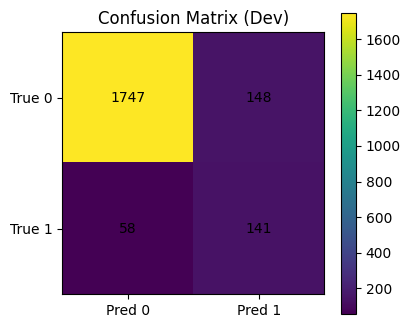

TN=1747, FP=148, FN=58, TP=141


In [16]:
import matplotlib.pyplot as plt

tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(
    {"Pred 0": [tn, fn], "Pred 1": [fp, tp]},
    index=["True 0", "True 1"]
)
display(cm_df)

plt.figure(figsize=(4.2, 3.6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Dev)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

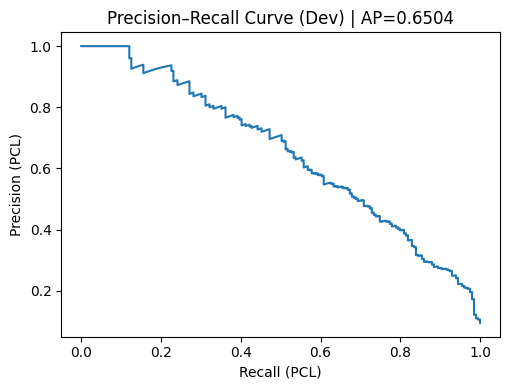

Closest threshold in PR array: 0.5495719
Precision at t*: 0.4862068965517241 Recall at t*: 0.7085427135678392


In [17]:
prec, rec, thr = precision_recall_curve(y_true, probs)
ap = average_precision_score(y_true, probs)

plt.figure(figsize=(5.2, 4.0))
plt.plot(rec, prec)
plt.title(f"Precision–Recall Curve (Dev) | AP={ap:.4f}")
plt.xlabel("Recall (PCL)")
plt.ylabel("Precision (PCL)")
plt.tight_layout()
plt.show()

# Show where the chosen threshold sits (approx)
# Find closest threshold index
if len(thr) > 0:
    idx = np.argmin(np.abs(thr - best_t))
    print("Closest threshold in PR array:", thr[idx])
    print("Precision at t*:", prec[idx], "Recall at t*:", rec[idx])

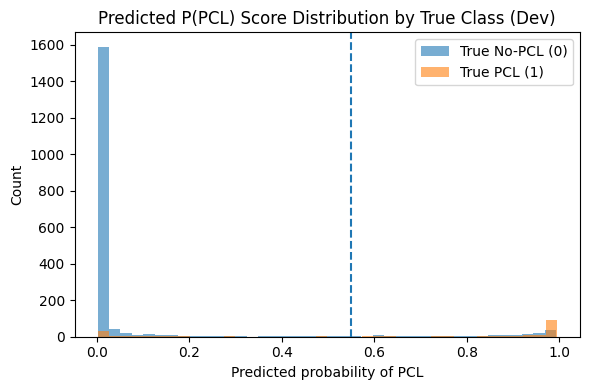

Mean P(PCL) for true 0: 0.08495628
Mean P(PCL) for true 1: 0.69248587


In [18]:
plt.figure(figsize=(6,4))
plt.hist(probs[y_true==0], bins=40, alpha=0.6, label="True No-PCL (0)")
plt.hist(probs[y_true==1], bins=40, alpha=0.6, label="True PCL (1)")
plt.axvline(best_t, linestyle="--")
plt.title("Predicted P(PCL) Score Distribution by True Class (Dev)")
plt.xlabel("Predicted probability of PCL")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean P(PCL) for true 0:", probs[y_true==0].mean())
print("Mean P(PCL) for true 1:", probs[y_true==1].mean())

In [19]:
analysis_df = dev_df.copy().reset_index(drop=True)
analysis_df["y_true"] = y_true
analysis_df["p_pcl"] = probs
analysis_df["y_pred"] = y_pred
analysis_df["error_type"] = "CORRECT"
analysis_df.loc[(analysis_df.y_true==0) & (analysis_df.y_pred==1), "error_type"] = "FP"
analysis_df.loc[(analysis_df.y_true==1) & (analysis_df.y_pred==0), "error_type"] = "FN"

analysis_df.head()

,par_id,text,label_bin,y_true,p_pcl,y_pred,error_type
0,107,"""His present """" chambers """" may be quite humbl...",1,1,0.005629,0,FN
1,149,Krueger recently harnessed that creativity to ...,1,1,0.105107,0,FN
2,151,10:41am - Parents of children who died must ge...,1,1,0.770314,1,CORRECT
3,154,When some people feel causing problem for some...,1,1,0.991472,1,CORRECT
4,157,We are alarmed to learn of your recently circu...,1,1,0.944896,1,CORRECT


In [20]:
def show_examples(df, error_type, n=8, most_confident=True):
    sub = df[df["error_type"] == error_type].copy()
    if sub.empty:
        print("No examples for", error_type)
        return
    # Sort by confidence
    if most_confident:
        if error_type == "FP":
            sub = sub.sort_values("p_pcl", ascending=False)
        elif error_type == "FN":
            sub = sub.sort_values("p_pcl", ascending=True)
    else:
        sub["dist_to_t"] = np.abs(sub["p_pcl"] - best_t)
        sub = sub.sort_values("dist_to_t", ascending=True)

    display(sub[["par_id","p_pcl","y_true","y_pred","error_type","text"]].head(n))

print("Most confident False Positives:")
show_examples(analysis_df, "FP", n=6, most_confident=True)

print("Most confident False Negatives:")
show_examples(analysis_df, "FN", n=6, most_confident=True)

Most confident False Positives:


,par_id,p_pcl,y_true,y_pred,error_type,text
585,8838,0.994012,0,1,FP,""""""" I always consider this job as a gift , bei..."
1064,9353,0.993908,0,1,FP,"""But more than taking personal strength from t..."
1040,9326,0.993210,0,1,FP,"The majority of these people now reside , in r..."
1252,9549,0.991450,0,1,FP,Usually children of poor families remember the...
715,8978,0.991216,0,1,FP,Jesus begins his teaching in Matthew with the ...
388,8626,0.990993,0,1,FP,""""""" Your personal leadership has been critical..."


Most confident False Negatives:


,par_id,p_pcl,y_true,y_pred,error_type,text
150,7414,0.001449,1,0,FN,Cheung said 20 disabled undergraduate students...
121,6234,0.001558,1,0,FN,The World Health Organization did not give a r...
1966,10326,0.001767,1,0,FN,A top health official said today that the gove...
35,1648,0.002624,1,0,FN,"""Mari ? tte Coetzee from Stofberg Family Viney..."
41,1870,0.003132,1,0,FN,"""He said : """" I think we can consider introduc..."
108,5722,0.003375,1,0,FN,"""Calling for an immediate political solution t..."


In [21]:
print("False Positives closest to threshold (borderline / ambiguous):")
show_examples(analysis_df, "FP", n=8, most_confident=False)

print("False Negatives closest to threshold (borderline / ambiguous):")
show_examples(analysis_df, "FN", n=8, most_confident=False)

False Positives closest to threshold (borderline / ambiguous):


,par_id,p_pcl,y_true,y_pred,error_type,text
1542,9875,0.550848,0,1,FP,"Columns Poor , pregnant and homeless"
540,8788,0.556656,0,1,FP,"""Dual Blessings is an organisation that looks ..."
950,9228,0.558038,0,1,FP,Across all sporting federations the picture pa...
1289,9589,0.558897,0,1,FP,Be persistent that the person should not be al...
955,9233,0.562698,0,1,FP,Le r ? ve Canadien : French immigrants find Ca...
671,8931,0.590672,0,1,FP,""""""" The UN Security Council must stand up and ..."
690,8950,0.609445,0,1,FP,""""""" We constantly have to face people squashin..."
1853,10205,0.609514,0,1,FP,Bridge2Aid is a dental charity that is working...


False Negatives closest to threshold (borderline / ambiguous):


,par_id,p_pcl,y_true,y_pred,error_type,text
115,5989,0.489810,1,0,FN,McAfee said he was helping the locals by feedi...
37,1693,0.483405,1,0,FN,""""""" They have made them to become hopeless and..."
128,6546,0.464139,1,0,FN,ICCCAD remains a strong advocate of local init...
1461,9788,0.432492,1,0,FN,TurkIt 's heartening to see that measures are ...
70,3672,0.369612,1,0,FN,"Yes , DMC you are very good at adding numbers ..."
129,6645,0.333231,1,0,FN,"""After the satisfying evening , Manny Osme ? a..."
579,8831,0.290587,1,0,FN,"It is also good news for women 's issues , whi..."
479,8722,0.279140,1,0,FN,But if the Supreme Court gives a favorable dec...


In [22]:
high_signal_phrases = [
    "the hungry", "a roof", "their poverty", "to donate", "the dignity", "prayer", "god"
]

pattern = "|".join([re.escape(p) for p in high_signal_phrases])
subset = analysis_df[analysis_df["text"].str.lower().str.contains(pattern, regex=True)].copy()

print("Subset size containing high-signal phrases:", subset.shape[0])
display(subset["error_type"].value_counts())

# Compare FP rate inside vs outside subset
def fp_rate(df):
    if (df["y_true"]==0).sum() == 0:
        return np.nan
    return ((df["error_type"]=="FP").sum()) / ((df["y_true"]==0).sum())

inside = subset
outside = analysis_df[~analysis_df.index.isin(subset.index)]

print("FP rate inside subset:", fp_rate(inside))
print("FP rate outside subset:", fp_rate(outside))

Subset size containing high-signal phrases: 28


error_type
CORRECT    20
FP          6
FN          2
Name: count, dtype: int64

FP rate inside subset: 0.4
FP rate outside subset: 0.07553191489361702


In [23]:
# Only run if those columns exist
for col in ["keyword", "country"]:
    if col in analysis_df.columns:
        grp = analysis_df.groupby(col).apply(
            lambda g: pd.Series({
                "n": len(g),
                "pos_rate_true": g["y_true"].mean(),
                "pos_rate_pred": g["y_pred"].mean(),
                "f1_pos": f1_score(g["y_true"], g["y_pred"], pos_label=1) if g["y_true"].nunique()>1 else np.nan
            })
        ).reset_index().sort_values("n", ascending=False)

        print(f"\nTop groups by size for {col}:")
        display(grp.head(15))

In [35]:
# Create a column where you can manually tag a small sample of errors.
# Suggested categories:
#  - "LEXICAL_SHORTCUT": charity/religion framing triggers FP
#  - "NEUTRAL_REPORTING": factual reporting misread as patronising (FP)
#  - "SUBTLE_CONDESCENSION": FN due to implicit framing
#  - "CONTEXT_MISSING": needs more context than paragraph provides
#  - "ANNOTATION_AMBIGUITY": borderline/noisy label

analysis_df["error_cause"] = ""

# Pull a manageable sample of errors for manual annotation
sample_errors = pd.concat([
    analysis_df[analysis_df.error_type=="FP"].sort_values("p_pcl", ascending=False).head(10),
    analysis_df[analysis_df.error_type=="FN"].sort_values("p_pcl", ascending=True).head(10),
], ignore_index=True)

display(sample_errors[["par_id","p_pcl","error_type","text","error_cause"]])
analysis_df.to_csv("sample_errors.csv", index=False)

,par_id,p_pcl,error_type,text,error_cause
0,8838,0.994012,FP,""""""" I always consider this job as a gift , bei...",
1,9353,0.993908,FP,"""But more than taking personal strength from t...",
2,9326,0.993210,FP,"The majority of these people now reside , in r...",
3,9549,0.991450,FP,Usually children of poor families remember the...,
4,8978,0.991216,FP,Jesus begins his teaching in Matthew with the ...,
5,8626,0.990993,FP,""""""" Your personal leadership has been critical...",
6,9576,0.990712,FP,"Miskia Ahmed , a 21-year-old female Somalia re...",
7,9540,0.989844,FP,"""She added : """" I am really happy with the awa...",
8,10277,0.989737,FP,""""""" This definitive outcome is a testament to ...",
9,9543,0.989389,FP,"Many of the children are from poor families , ...",
